# 11 — Randomized Controlled Trials (RCT)
**Key references:** Fisher (1935) · Neyman (1923) · Rosenbaum (2002) · Duflo, Glennerster & Kremer (2007) · Imbens & Rubin (2015) · Kohavi, Tang & Xu (2020)

---

## Narrative thread — experiment lifecycle

```
PRE-EXPERIMENT
  Section 1 — Power analysis      How many subjects? MDE, sigma, duration
  Section 2 — Randomization design   Complete vs stratified vs paired

EXECUTION
  Section 3 — Balance check       Did randomization work? SMD, F-test
  Section 4 — ATE estimation      Diff-in-means, Lin (2013), CUPED
  Section 5 — CUPED deep dive     Why it works, variance reduction = rho^2, FWL connection

INFERENCE
  Section 6 — Randomization inference   Fisher exact test, no distributional assumptions
  Section 7 — Threats to validity       Non-compliance (ITT vs LATE), attrition, SUTVA

A/B TESTING
  Section 8 — Sample Ratio Mismatch    Chi-square SRM test, common causes
```

---

## Notation

| Symbol | Definition |
|---|---|
| $Y_i(1),\, Y_i(0)$ | Potential outcomes with/without treatment (Rubin, 1974) |
| $\tau_i = Y_i(1) - Y_i(0)$ | Individual treatment effect (never fully observable) |
| $ATE = E[\tau_i]$ | Average Treatment Effect — over the full population |
| $ATT = E[\tau_i \mid D_i=1]$ | Average Treatment Effect on the Treated |
| $Z_i \in \{0,1\}$ | Treatment *assignment* (the randomized instrument) |
| $D_i \in \{0,1\}$ | Treatment *receipt* (may differ from $Z_i$ under non-compliance) |
| $n_T,\, n_C$ | Number of treated and control units |
| $\bar{Y}_T,\, \bar{Y}_C$ | Sample means in treatment and control |
| $\sigma^2$ | Variance of the outcome |
| $\Delta$ | Minimum Detectable Effect (MDE) |
| $\alpha$ | Significance level (type I error) |
| $1-\beta$ | Statistical power (1 - type II error) |
| $\rho$ | Correlation between $Y$ and $X^{pre}$ — governs CUPED variance reduction |

---

## Why randomization is the gold standard

In observational studies, CIA ($Y(0) \perp D \mid X$) requires observing *all* confounders.
Randomization achieves something stronger: **unconditional independence**

$$Y(0),\, Y(1) \perp D$$

so both potential outcomes are independent of treatment assignment.
This means $E[Y(0) \mid D=1] = E[Y(0) \mid D=0]$ — **selection bias is exactly zero**:

$$E[Y \mid D=1] - E[Y \mid D=0] = E[Y(1) - Y(0)] = ATE$$

No controls needed. No CIA. No functional form assumptions.

In [18]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import combinations

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima'
})
np.random.seed(42)

# Context: RCT of a microcredit subsidy program in rural households
# Inspired by Duflo, Kremer & Robinson (2011) — fertilizer adoption in Kenya
# Treatment: microcredit subsidy
# Outcome: annual household income (USD)

n = 1200
TRUE_ATE = 150.0   # USD additional income per year

# Pre-treatment covariates (available before randomization)
age        = np.random.randint(25, 65, n).astype(float)
hh_size    = np.random.poisson(4.5, n).astype(float)
land_ha    = np.clip(np.random.exponential(1.5, n), 0.1, 10)
baseline_y = 200 + 80*land_ha + np.random.normal(0, 120, n)

# COMPLETE RANDOMIZATION (50/50)
D = np.zeros(n, dtype=float)
D[np.random.choice(n, n//2, replace=False)] = 1

# Potential outcomes (heterogeneous effect by land_ha)
Y0 = baseline_y + np.random.normal(0, 80, n)
Y1 = Y0 + TRUE_ATE + 30*(land_ha - land_ha.mean())
Y  = np.where(D==1, Y1, Y0)

df = pd.DataFrame({
    'Y': Y, 'Y0': Y0, 'Y1': Y1, 'D': D,
    'age': age, 'hh_size': hh_size, 'land_ha': land_ha,
    'baseline_y': baseline_y, 'tau_i': Y1 - Y0,
})

print(f'RCT: n={n}  Treated={D.sum():.0f}  Controls={(1-D).sum():.0f}')
print(f'True ATE: {df["tau_i"].mean():.2f} USD')

RCT: n=1200  Treated=600  Controls=600
True ATE: 150.00 USD


## Section 1 — Power analysis, sample size and experiment duration

The first question before running any experiment: **how many subjects do we need?**

### The standard formula

$$n = \frac{(z_{\alpha/2} + z_\beta)^2 \cdot 2\sigma^2}{\Delta^2}$$

| Input | Symbol | Typical value | Effect on $n$ |
|---|---|---|---|
| Significance level | $\alpha$ | 0.05 | Lower $\alpha$ → higher $n$ |
| Power | $1-\beta$ | 0.80 or 0.90 | Higher power → higher $n$ |
| Outcome SD | $\sigma$ | From pilot or literature | Higher $\sigma$ → higher $n$ |
| Min Detectable Effect | $\Delta$ | Policy-relevant threshold | Smaller $\Delta$ → higher $n$ (quadratic!) |

The **MDE** is the smallest effect size worth detecting from a policy standpoint —
not the expected effect. If a $100 income gain would not change any policy decision,
set MDE = 100.

---

### Where the formula comes from

The sample size formula is obtained by **inverting the two-sample t-test**.

**Step 1 — Write the t-statistic under the true effect $\Delta$.**

With $n_T = n_C = n/2$ and outcome variance $\sigma^2$ in both arms, the
difference-in-means estimator has standard error:
$$SE = \sqrt{\frac{\sigma^2}{n/2} + \frac{\sigma^2}{n/2}} = \sigma\sqrt{\frac{2}{n}}$$

The t-statistic when the true effect is $\Delta$ is:
$$t = \frac{\hat{\tau}}{SE} \approx \frac{\Delta}{\sigma\sqrt{2/n}}$$

**Step 2 — State the two error conditions.**

We want to control two probabilities simultaneously:

| Error | Condition | Requirement |
|---|---|---|
| Type I (false positive) | Reject $H_0$ when $\Delta = 0$ | critical value $= z_{\alpha/2}$ |
| Type II (false negative) | Fail to reject when $\Delta > 0$ | non-centrality $\geq z_\beta$ |

For the test to have power $1-\beta$, the non-centrality of $t$ under the true
effect must clear the sum of both critical values:
$$\frac{\Delta}{\sigma\sqrt{2/n}} \geq z_{\alpha/2} + z_\beta$$

**Step 3 — Solve for $n$.**

Square both sides and rearrange:
$$\boxed{n \geq \frac{(z_{\alpha/2} + z_\beta)^2 \cdot 2\sigma^2}{\Delta^2}}$$

Round up to the nearest integer — that is `required_n` in the code below.

> **Why $\Delta^2$ in the denominator?** The signal-to-noise ratio $\Delta/\sigma$ enters
> squared. Halving the MDE requires **four times** as many subjects. This quadratic
> relationship is the single most important design insight in power analysis.

**General case — unequal allocation.**

If a fraction $p$ goes to treatment and $1-p$ to control, the SE generalizes to
$\sigma / \sqrt{n \cdot p(1-p)}$, and the formula becomes:
$$n = \frac{(z_{\alpha/2} + z_\beta)^2 \cdot \sigma^2}{\Delta^2 \cdot p(1-p)}$$

The denominator $p(1-p)$ is maximized at $p = 0.5$ — **equal allocation is optimal**.
Any deviation from 50/50 inflates the required $n$:

| Allocation (T/C) | $p(1-p)$ | $n$ relative to 50/50 |
|---|---|---|
| 50 / 50 | 0.250 | 1.00 $\times$ (minimum) |
| 60 / 40 | 0.240 | 1.04 $\times$ |
| 70 / 30 | 0.210 | 1.19 $\times$ |
| 80 / 20 | 0.160 | 1.56 $\times$ |

This is why `required_n` takes a `ratio` argument: passing `ratio=0.5` recovers the
standard $2\sigma^2$ form; any other value increases $n$ by $1/(4 \cdot p(1-p))$.

---

### Does experiment duration matter?

Duration is not in the formula directly, but enters through four channels:

| Channel | Mechanism | How to account for it |
|---|---|---|
| **Arrival rate** | $n(T) = \lambda \cdot T$ | $T^* = n^*/\lambda$ — the main driver in A/B testing |
| **Accumulating outcome** | $\sigma^2$ and $\Delta$ both grow with $T$ | Specify $\Delta$ per-period; SNR roughly constant |
| **CUPED pre-window** | Longer $X^{pre}$ window → higher $\rho$ → lower $\sigma_{eff}$ | $\sigma_{eff} = \sigma\sqrt{1-\rho^2}$ |
| **Novelty / day-of-week** | Behavioral artifacts in the first few days | Run $\geq$ 1 full user cycle (min 1 week) |

> **Kohavi, Tang & Xu (2020):** "Run experiments for at least one to two weeks to
> avoid day-of-week effects and allow novelty effects to diminish." 

Power Analysis — Duflo, Glennerster & Kremer (2007)
sigma_Y        = 214.9 USD  (without variance reduction)
rho(Y, X_pre)  = 0.848  ->  sigma_Y_cuped = 113.8 USD

       MDE   n (80% power)   n (90% power)   n (80%+CUPED)   % saved
--------------------------------------------------------------------
MDE=  50 USD             581             777             163       72%
MDE= 100 USD             146             195              41       72%
MDE= 150 USD              65              87              19       71%
MDE= 200 USD              37              49              11       70%
MDE= 250 USD              24              32               7       71%

If arrival rate lambda=200 users/day:
  Duration (no CUPED):   0 days  (n=65)
  Duration (with CUPED): 0 days  (n=19)


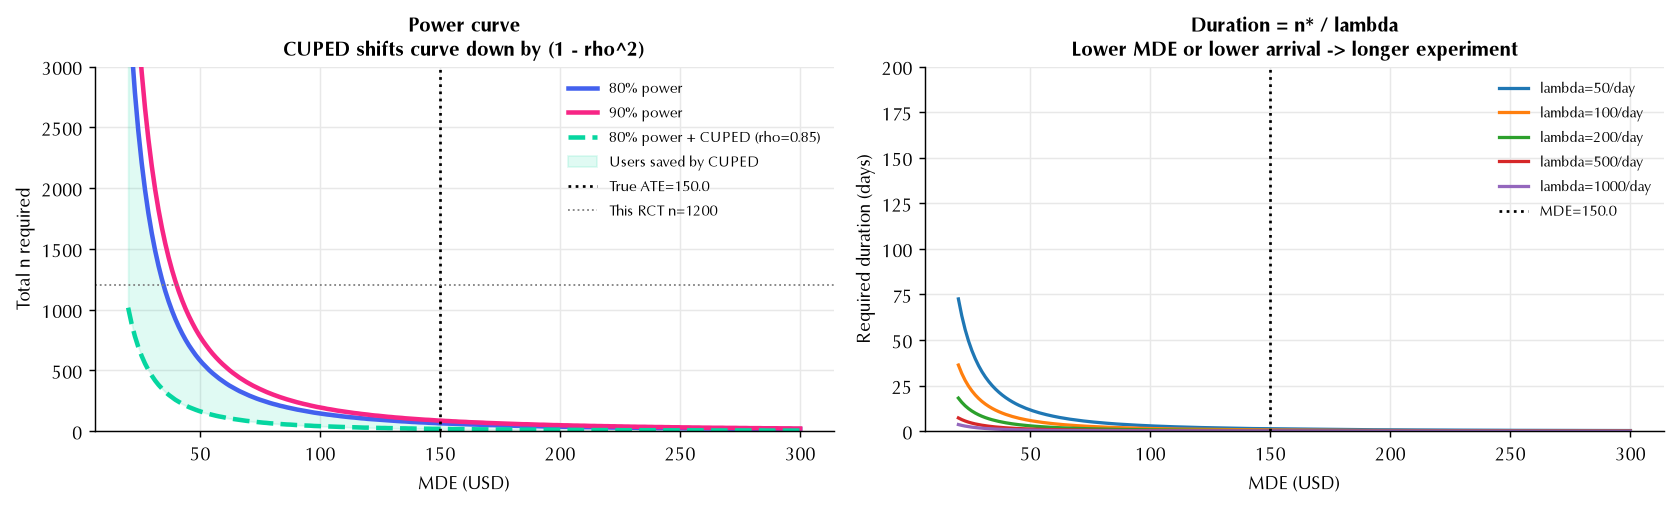

In [19]:
from scipy.stats import norm as normal

def required_n(mde, sigma, alpha=0.05, power=0.80, ratio=0.5):
    """Total sample size to detect MDE at given power.
    ratio = fraction assigned to treatment (0.5 = 50/50).
    """
    z_alpha = normal.ppf(1 - alpha/2)
    z_beta  = normal.ppf(power)
    return int(np.ceil((z_alpha + z_beta)**2 * sigma**2 / (mde**2 * ratio * (1-ratio))))

sigma_y = df['Y'].std()

# Approximate CUPED sigma using rho from pre-experiment data
# (rho_cuped is estimated precisely in Section 5; here we preview its effect)
rho_preview     = np.corrcoef(df['Y'], df['baseline_y'])[0,1]
sigma_y_cuped   = sigma_y * np.sqrt(1 - rho_preview**2)

print('Power Analysis — Duflo, Glennerster & Kremer (2007)')
print(f'sigma_Y        = {sigma_y:.1f} USD  (without variance reduction)')
print(f'rho(Y, X_pre)  = {rho_preview:.3f}  ->  sigma_Y_cuped = {sigma_y_cuped:.1f} USD')
print()
print(f'{"MDE":>10}  {"n (80% power)":>14}  {"n (90% power)":>14}  {"n (80%+CUPED)":>14}  {"% saved":>8}')
print('-' * 68)
for mde in [50, 100, 150, 200, 250]:
    n80  = required_n(mde, sigma_y,     power=0.80)
    n90  = required_n(mde, sigma_y,     power=0.90)
    n80c = required_n(mde, sigma_y_cuped, power=0.80)
    print(f'MDE={mde:>4} USD  {n80:>14,}  {n90:>14,}  {n80c:>14,}  {(1-n80c/n80)*100:>7.0f}%')

# Arrival rate: how long to run?
lam = 200   # users per day (hypothetical)
n_target_80 = required_n(TRUE_ATE, sigma_y, power=0.80)
n_target_80c = required_n(TRUE_ATE, sigma_y_cuped, power=0.80)
print(f'\nIf arrival rate lambda={lam} users/day:')
print(f'  Duration (no CUPED):   {n_target_80/lam:.0f} days  (n={n_target_80:,})')
print(f'  Duration (with CUPED): {n_target_80c/lam:.0f} days  (n={n_target_80c:,})')

mdes  = np.linspace(20, 300, 200)
n_80_arr   = [required_n(d, sigma_y,       power=0.80) for d in mdes]
n_90_arr   = [required_n(d, sigma_y,       power=0.90) for d in mdes]
n_80c_arr  = [required_n(d, sigma_y_cuped, power=0.80) for d in mdes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(mdes, n_80_arr,  color='#4361ee', linewidth=2.5, label='80% power')
ax.plot(mdes, n_90_arr,  color='#f72585', linewidth=2.5, label='90% power')
ax.plot(mdes, n_80c_arr, color='#06d6a0', linewidth=2.5, linestyle='--',
        label=f'80% power + CUPED (rho={rho_preview:.2f})')
ax.fill_between(mdes, n_80c_arr, n_80_arr, alpha=0.12, color='#06d6a0', label='Users saved by CUPED')
ax.axvline(TRUE_ATE, color='black', linewidth=1.5, linestyle=':', label=f'True ATE={TRUE_ATE}')
ax.axhline(n, color='gray', linewidth=1, linestyle=':', label=f'This RCT n={n}')
ax.set_xlabel('MDE (USD)'); ax.set_ylabel('Total n required')
ax.set_title('Power curve\nCUPED shifts curve down by (1 - rho^2)')
ax.legend(fontsize=8); ax.set_ylim(0, 3000)

ax2 = axes[1]
arrival_rates = [50, 100, 200, 500, 1000]
mde_fixed = TRUE_ATE
for lam_i in arrival_rates:
    durations = [required_n(d, sigma_y, power=0.80) / lam_i for d in mdes]
    ax2.plot(mdes, durations, linewidth=1.8, label=f'lambda={lam_i}/day')
ax2.axvline(mde_fixed, color='black', linewidth=1.5, linestyle=':', label=f'MDE={mde_fixed}')
ax2.set_xlabel('MDE (USD)'); ax2.set_ylabel('Required duration (days)')
ax2.set_title('Duration = n* / lambda\nLower MDE or lower arrival -> longer experiment')
ax2.legend(fontsize=8); ax2.set_ylim(0, 200)

plt.tight_layout()
plt.show()

---

## Special topic — Multi-arm experiments

### Setup

A multi-arm experiment has one control group ($C$) and $K$ treatment variants
($T_1, \ldots, T_K$). Each arm tests a different version of the intervention —
e.g., three pricing strategies, four UI layouts, or a dose-response sequence.

Two problems arise that do not exist in a two-arm design:

1. **Sample size** — how do you allocate $n$ subjects across $K+1$ arms?
2. **Multiple comparisons** — running $K$ tests simultaneously inflates the
   family-wise error rate (FWER) above $\alpha$.

---

### Problem 1 — Sample size and optimal allocation

Each pairwise comparison (variant $k$ vs. control) requires:
$$n_k + n_C \geq \frac{(z_{\alpha/2} + z_\beta)^2 \cdot \sigma^2}{\Delta^2} \cdot \left(\frac{1}{p_k} + \frac{1}{p_C}\right)$$

where $p_k = n_k/n$ and $p_C = n_C/n$ are the allocation fractions.

**The control bottleneck.** Each variant is compared against the same control group.
The control arm is shared across all $K$ comparisons, so it is the bottleneck: it
needs to be larger than any single variant arm.

**Optimal allocation (Dunnett, 1955):**
$$p_C^* = \frac{\sqrt{K}}{\sqrt{K} + K} = \frac{1}{1 + \sqrt{K}} \qquad p_k^* = \frac{1 - p_C^*}{K} \quad \forall k$$

This minimizes total $n$ for a fixed power level. Equal allocation across all $K+1$
arms ($p = 1/(K+1)$) is suboptimal and requires more subjects:

| Arms ($K$ variants) | Optimal $p_C$ | Equal $p_C$ | Extra $n$ vs optimal |
|---|---|---|---|
| 1 | 0.500 | 0.500 | 0% |
| 2 | 0.414 | 0.333 | ~6% |
| 3 | 0.366 | 0.250 | ~12% |
| 4 | 0.333 | 0.200 | ~16% |
| 9 | 0.250 | 0.100 | ~29% |

**Intuition:** as $K$ grows, the control group needs to "serve" more comparisons,
so it should receive a disproportionately larger share of traffic.

---

### Problem 2 — Multiple comparisons and FWER

Running $K$ independent tests each at level $\alpha$ means the probability of at
least one false positive is:
$$\text{FWER} = 1 - (1 - \alpha)^K$$

| $K$ tests | FWER at $\alpha = 0.05$ |
|---|---|
| 1 | 5.0% |
| 2 | 9.8% |
| 3 | 14.3% |
| 5 | 22.6% |
| 10 | 40.1% |

**Three standard corrections:**

| Method | Adjusted $\alpha$ | Power | When to use |
|---|---|---|---|
| **Bonferroni** | $\alpha / K$ | Conservative | Any structure; simple; default |
| **Holm (1979)** | Step-down Bonferroni | Less conservative than Bonferroni | Same as Bonferroni but uniformly better |
| **Benjamini-Hochberg (1995)** | Controls FDR, not FWER | Highest power | Exploratory; many variants; accept some FP |

Bonferroni increases the required $n$ by a factor of approximately
$\left(\frac{z_{\alpha/(2K)} + z_\beta}{z_{\alpha/2} + z_\beta}\right)^2$
relative to a single two-arm test at the same power.

---

### End-to-end rule of thumb

> Run $K$ variants + 1 control? Use Dunnett allocation for traffic split,
> Bonferroni (or Holm) for inference, and budget for the extra $n$ both require.
> If you are in an exploratory phase with many low-cost variants, switch to
> Benjamini-Hochberg to preserve statistical power.

In [ ]:
# ── Multi-arm experiments: allocation and multiple comparisons ────────────

from scipy.stats import norm as normal
from statsmodels.stats.multitest import multipletests

# ── 1. Optimal Dunnett allocation vs equal allocation ────────────────────
K_range = np.arange(1, 11)

def dunnett_alloc(K):
    p_C = 1 / (1 + np.sqrt(K))
    p_k = (1 - p_C) / K
    return p_C, p_k

def n_multiarm(K, mde, sigma, alpha=0.05, power=0.80, use_dunnett=True):
    """Total n for K variants + 1 control.
    Each variant is compared against control; Bonferroni correction applied.
    """
    alpha_adj = alpha / K           # Bonferroni
    z_a = normal.ppf(1 - alpha_adj / 2)
    z_b = normal.ppf(power)
    if use_dunnett:
        p_C, p_k = dunnett_alloc(K)
    else:
        p_C = p_k = 1 / (K + 1)    # equal allocation
    # n needed per comparison (variant k vs control)
    n_per_comparison = np.ceil((z_a + z_b)**2 * sigma**2 / mde**2 * (1/p_k + 1/p_C))
    # total n: control + K variants
    # control serves all comparisons; its size is set by the largest bottleneck
    n_C   = np.ceil(n_per_comparison * p_C / (p_k + p_C))
    n_k   = np.ceil(n_per_comparison * p_k / (p_k + p_C))
    return int(n_C + K * n_k)

mde_ma  = TRUE_ATE
sig_ma  = sigma_y

print('Multi-arm sample size: Dunnett (optimal) vs Equal allocation')
print(f'MDE={mde_ma} USD  sigma={sig_ma:.1f}  alpha=0.05 (Bonferroni)  power=80%')
print()
print(f'{"K variants":>10}  {"p_C (Dunnett)":>14}  {"n (Dunnett)":>12}  {"n (Equal)":>10}  {"Extra n":>8}')
print('-' * 62)
for K in K_range:
    p_C_d, _ = dunnett_alloc(K)
    n_d = n_multiarm(K, mde_ma, sig_ma, use_dunnett=True)
    n_e = n_multiarm(K, mde_ma, sig_ma, use_dunnett=False)
    print(f'{K:>10}  {p_C_d:>14.3f}  {n_d:>12,}  {n_e:>10,}  {(n_e/n_d - 1)*100:>7.1f}%')

# ── 2. FWER inflation ────────────────────────────────────────────────────
print('\nFWER inflation with K simultaneous tests (alpha=0.05 per test)')
for K in [1, 2, 3, 5, 10]:
    fwer = 1 - (1 - 0.05)**K
    print(f'  K={K:>2}  FWER={fwer*100:.1f}%')

# ── 3. Simulate a 3-arm experiment and apply corrections ──────────────────
np.random.seed(42)
K_sim     = 3
n_per_arm = 300

# True effects: variant 1 works, variants 2 and 3 are null
true_effects = [TRUE_ATE, 0.0, 0.0]
Y_control = df['Y0'].sample(n_per_arm, replace=True).values

p_values = []
estimates = []
for k, eff in enumerate(true_effects):
    Y_k  = df['Y0'].sample(n_per_arm, replace=True).values + eff + np.random.normal(0, sigma_y, n_per_arm)
    t, p = stats.ttest_ind(Y_k, Y_control)
    ate_k = Y_k.mean() - Y_control.mean()
    p_values.append(p)
    estimates.append(ate_k)

# Apply multiple comparison corrections
_, p_bonf,  _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
_, p_holm,  _, _ = multipletests(p_values, alpha=0.05, method='holm')
_, p_bh,    _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f'\n3-arm simulation: 1 true effect (ATE={TRUE_ATE}), 2 null variants')
print(f'  n per arm = {n_per_arm}  |  True effects = {true_effects}')
print()
print(f'{"Variant":>10}  {"ATE est.":>10}  {"p (raw)":>10}  {"p (Bonf)":>10}  {"p (Holm)":>10}  {"p (BH)":>10}  {"True":>6}')
print('-' * 75)
for k in range(K_sim):
    truth = 'signal' if true_effects[k] > 0 else 'null'
    print(f'Variant {k+1:>2}  {estimates[k]:>10.2f}  {p_values[k]:>10.4f}  {p_bonf[k]:>10.4f}  {p_holm[k]:>10.4f}  {p_bh[k]:>10.4f}  {truth:>6}')

# ── 4. Visualize ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: optimal vs equal n by K
K_arr = np.arange(1, 11)
n_dun = [n_multiarm(K, mde_ma, sig_ma, use_dunnett=True)  for K in K_arr]
n_eql = [n_multiarm(K, mde_ma, sig_ma, use_dunnett=False) for K in K_arr]
axes[0].plot(K_arr, n_dun, color='#4361ee', linewidth=2.5, marker='o', label='Dunnett (optimal)')
axes[0].plot(K_arr, n_eql, color='#f72585', linewidth=2.5, marker='s', linestyle='--', label='Equal allocation')
axes[0].fill_between(K_arr, n_dun, n_eql, alpha=0.12, color='#f72585', label='Wasted subjects')
axes[0].set_xlabel('K (number of variants)')
axes[0].set_ylabel('Total n required')
axes[0].set_title('Dunnett vs Equal Allocation\nOptimal control share = 1/(1+sqrt(K))')
axes[0].legend(fontsize=9)

# Panel 2: FWER vs K
K_fwer = np.arange(1, 21)
fwer_uncorrected = 1 - (1 - 0.05)**K_fwer
fwer_bonf        = 1 - (1 - 0.05/K_fwer)**K_fwer
axes[1].plot(K_fwer, fwer_uncorrected * 100, color='#f72585', linewidth=2.5, label='No correction')
axes[1].plot(K_fwer, fwer_bonf * 100,        color='#4361ee', linewidth=2.5, label='Bonferroni')
axes[1].axhline(5, color='black', linewidth=1.5, linestyle=':', label='alpha=5%')
axes[1].set_xlabel('K (number of variants)')
axes[1].set_ylabel('FWER (%)')
axes[1].set_title('FWER inflation with K tests\nBonferroni keeps FWER <= alpha')
axes[1].legend(fontsize=9)

# Panel 3: Dunnett optimal p_C as a function of K
p_C_arr = [dunnett_alloc(K)[0] for K in K_arr]
p_eq    = [1/(K+1) for K in K_arr]
axes[2].plot(K_arr, p_C_arr, color='#4361ee', linewidth=2.5, marker='o', label='Dunnett p_C*')
axes[2].plot(K_arr, p_eq,    color='#f72585', linewidth=2.5, marker='s', linestyle='--', label='Equal p_C = 1/(K+1)')
axes[2].set_xlabel('K (number of variants)')
axes[2].set_ylabel('Control allocation p_C')
axes[2].set_title('Optimal control share (Dunnett, 1955)\np_C* = 1 / (1 + sqrt(K))')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Section 2 — Randomization designs

### The design decision comes before randomizing

The choice of randomization design is made at the planning stage — it affects
**variance** (stratification and pairing reduce SE by eliminating between-group
variation from the estimator) and **validity** (cluster randomization prevents
SUTVA violations when units interact).

| Design | How | SE vs complete | When |
|---|---|---|---|
| **Complete** | Draw $m$ of $N$ uniformly | Baseline | Default |
| **Stratified** | Randomize within strata of $X$ | Lower (between-strata variance removed) | Predictive covariate known |
| **Paired** | Form pairs on $X$; assign one per pair | Lowest (maximum between-unit variance removed) | Strong covariate, small $n$ |
| **Clustered** | Randomize at group level | Higher (ICC inflates variance) | Spillovers or logistical constraints |

### Why pairing reduces variance

**Paired estimator:** $\hat{\tau}_{paired} = \frac{1}{n/2}\sum_j (Y_{j,T} - Y_{j,C})$

The variance of each within-pair difference is:
$$\text{Var}(Y_{j,T} - Y_{j,C}) = \text{Var}(Y(1)) + \text{Var}(Y(0)) - 2\,\text{Cov}(Y(1), Y(0))$$

Pairing removes $2\,\text{Cov}(Y(1), Y(0))$ from the variance. The gain is largest
when the matching variable strongly predicts outcomes in both arms — i.e., when
$\text{Cov}(Y(1), Y(0))$ is large, which happens precisely when $\rho(X, Y)$ is large.

> **Connection to CUPED (Section 5):** both pairing and CUPED reduce variance by
> leveraging $\rho(Y, X^{pre})$. Pairing removes between-pair variance by design;
> CUPED removes it analytically after the fact. With perfect matching they give
> identical variance reductions.

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_29122/2569407937.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (df[df['stratum']==s][df['D_strat']==1]['Y_strat'].var() / (len(df[df['stratum']==s])//2) +
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_29122/2569407937.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['stratum']==s][df['D_strat']==0]['Y_strat'].var() / (len(df[df['stratum']==s])//2))
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_29122/2569407937.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (df[df['stratum']==s][df['D_strat']==1]['Y_strat'].var() / (len(df[df['stratum']==s])//2) +
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_29122/2569407937.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['stratum']==s][df['D_strat']==0]['Y_strat'].var() / (len(df[df['stratum']==s

Variance Reduction Across Randomization Designs
True ATE: 150.0000
Design                                   ATE       SE SE reduction
----------------------------------------------------------
Complete (n=1200)                   163.8917  11.4762 baseline
Stratified (n=1200)                 150.7344   9.5025 +17.2%
Complete (n=100)                    109.6083  40.2316 (small n)
Paired (n=100)                      164.1991  30.1031 +25.2%


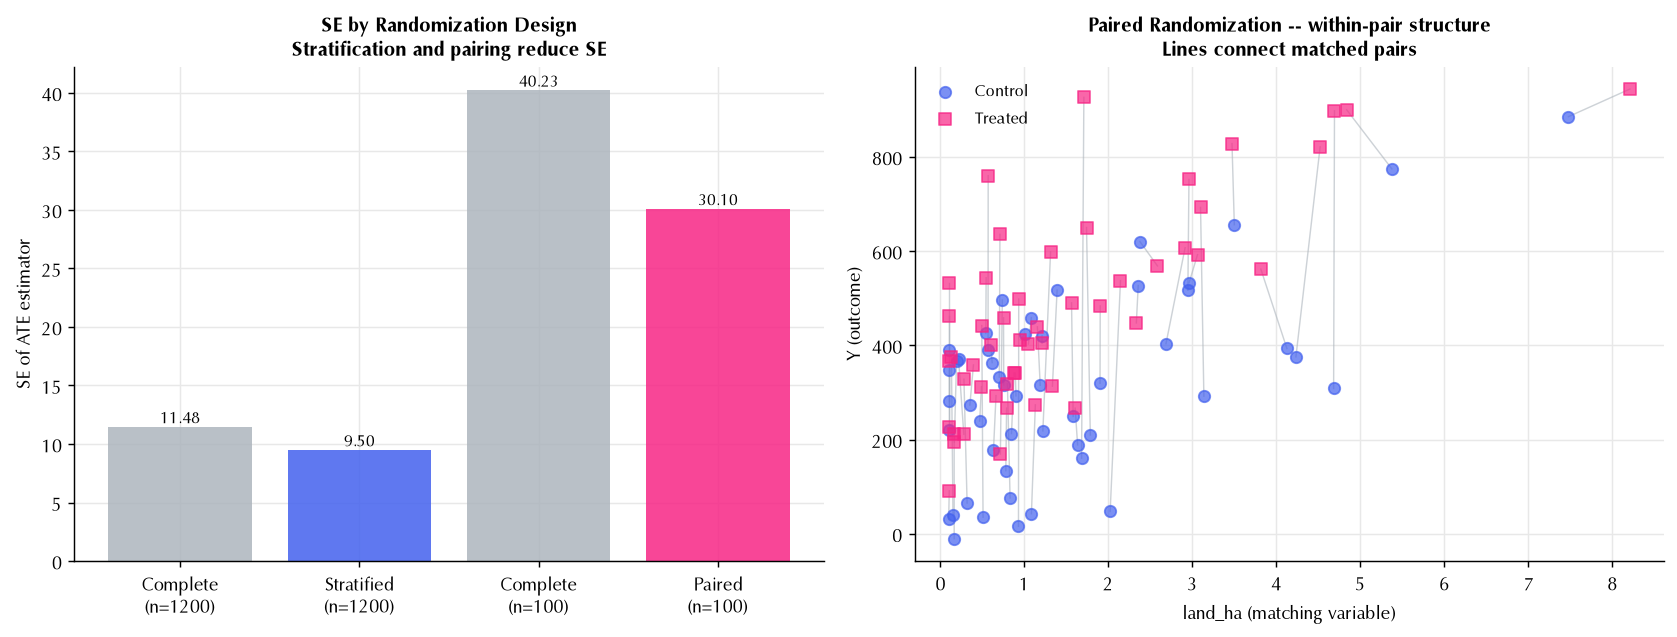

In [20]:
# Stratify by quartiles of land_ha (the covariate most correlated with Y)
df['stratum'] = pd.qcut(df['land_ha'], q=4, labels=[0, 1, 2, 3])

# STRATIFIED RANDOMIZATION: exactly 50% treated within each stratum
df['D_strat'] = 0.0
for s in [0, 1, 2, 3]:
    idx = df[df['stratum'] == s].index
    n_s = len(idx)
    treat_idx = np.random.choice(idx, n_s // 2, replace=False)
    df.loc[treat_idx, 'D_strat'] = 1.0

df['Y_strat'] = np.where(df['D_strat']==1, df['Y1'], df['Y0'])

# Post-stratification estimator
ate_strat = 0.0
for s in [0, 1, 2, 3]:
    sub = df[df['stratum'] == s]
    w   = len(sub) / n
    ate_strat += w * (sub[sub['D_strat']==1]['Y_strat'].mean() -
                      sub[sub['D_strat']==0]['Y_strat'].mean())

se_strat = np.sqrt(sum(
    (len(df[df['stratum']==s]) / n)**2 *
    (df[df['stratum']==s][df['D_strat']==1]['Y_strat'].var() / (len(df[df['stratum']==s])//2) +
     df[df['stratum']==s][df['D_strat']==0]['Y_strat'].var() / (len(df[df['stratum']==s])//2))
    for s in [0, 1, 2, 3]
))

# PAIRED RANDOMIZATION on a small subsample to show the mechanics
n_small = 100
df_small = df.sample(n_small, random_state=0).copy().reset_index(drop=True)
# Sort by land_ha and form pairs
df_small = df_small.sort_values('land_ha').reset_index(drop=True)
df_small['pair_id'] = np.repeat(np.arange(n_small // 2), 2)
df_small['D_pair'] = 0.0
for pid in range(n_small // 2):
    pair_idx = df_small[df_small['pair_id'] == pid].index
    treated  = np.random.choice(pair_idx, 1)
    df_small.loc[treated, 'D_pair'] = 1.0

df_small['Y_pair'] = np.where(df_small['D_pair']==1, df_small['Y1'], df_small['Y0'])

# Paired estimator: mean of within-pair differences
within_pair_diffs = []
for pid in range(n_small // 2):
    pair = df_small[df_small['pair_id'] == pid]
    y_t  = pair[pair['D_pair']==1]['Y_pair'].values
    y_c  = pair[pair['D_pair']==0]['Y_pair'].values
    diff = float(y_t[0]) - float(y_c[0]) if len(y_t) > 0 and len(y_c) > 0 else 0.0
    within_pair_diffs.append(diff)

ate_paired = np.mean(within_pair_diffs)
se_paired  = np.std(within_pair_diffs, ddof=1) / np.sqrt(n_small // 2)

# Complete randomization on the same small subsample for comparison
D_complete_s = np.zeros(n_small)
D_complete_s[np.random.choice(n_small, n_small//2, replace=False)] = 1
Y_complete_s = np.where(D_complete_s==1, df_small['Y1'], df_small['Y0'])
ate_complete_s = Y_complete_s[D_complete_s==1].mean() - Y_complete_s[D_complete_s==0].mean()
se_complete_s  = np.sqrt(Y_complete_s[D_complete_s==1].var()/(n_small//2) +
                          Y_complete_s[D_complete_s==0].var()/(n_small//2))

# Full-sample comparison
ate_dm_full = df[df['D']==1]['Y'].mean() - df[df['D']==0]['Y'].mean()
se_dm_full  = np.sqrt(df[df['D']==1]['Y'].var()/D.sum() + df[df['D']==0]['Y'].var()/(1-D).sum())

print('Variance Reduction Across Randomization Designs')
print('=' * 58)
print(f'True ATE: {df["tau_i"].mean():.4f}')
print(f'{"Design":<35} {"ATE":>8} {"SE":>8} {"SE reduction"}')
print('-' * 58)
print(f'{"Complete (n=1200)":<35} {ate_dm_full:>8.4f} {se_dm_full:>8.4f} {"baseline"}')
print(f'{"Stratified (n=1200)":<35} {ate_strat:>8.4f} {se_strat:>8.4f} {(1-se_strat/se_dm_full)*100:>+.1f}%')
print(f'{"Complete (n=100)":<35} {ate_complete_s:>8.4f} {se_complete_s:>8.4f} {"(small n)"}')
print(f'{"Paired (n=100)":<35} {ate_paired:>8.4f} {se_paired:>8.4f} {(1-se_paired/se_complete_s)*100:>+.1f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: SE comparison across designs
designs = ['Complete\n(n=1200)', 'Stratified\n(n=1200)', 'Complete\n(n=100)', 'Paired\n(n=100)']
ses_all = [se_dm_full, se_strat, se_complete_s, se_paired]
colors_d = ['#adb5bd', '#4361ee', '#adb5bd', '#f72585']
axes[0].bar(designs, ses_all, color=colors_d, alpha=0.85)
for i, se in enumerate(ses_all):
    axes[0].text(i, se + 0.3, f'{se:.2f}', ha='center', fontsize=9)
axes[0].set_ylabel('SE of ATE estimator')
axes[0].set_title('SE by Randomization Design\nStratification and pairing reduce SE')

# Panel 2: within-pair structure
axes[1].scatter(df_small[df_small['D_pair']==0]['land_ha'],
                df_small[df_small['D_pair']==0]['Y_pair'],
                s=40, color='#4361ee', alpha=0.7, label='Control', zorder=3)
axes[1].scatter(df_small[df_small['D_pair']==1]['land_ha'],
                df_small[df_small['D_pair']==1]['Y_pair'],
                s=40, color='#f72585', alpha=0.7, marker='s', label='Treated', zorder=3)
for pid in range(n_small // 2):
    pair = df_small[df_small['pair_id'] == pid]
    axes[1].plot(pair['land_ha'].values, pair['Y_pair'].values,
                 color='#adb5bd', linewidth=0.8, alpha=0.6, zorder=1)
axes[1].set_xlabel('land_ha (matching variable)')
axes[1].set_ylabel('Y (outcome)')
axes[1].set_title('Paired Randomization -- within-pair structure\nLines connect matched pairs')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 3 — Balance check: did randomization work?

### Why balance matters

Randomization guarantees balance **in expectation**, not in every realized sample.
With finite $n$, chance imbalances occur. A balance check verifies that the realized
assignment did not produce a sample where treated and controls differ substantially
on pre-treatment covariates.

**What to check:**
- Individual t-tests for each covariate: $H_0: E[X_j \mid D=1] = E[X_j \mid D=0]$
- Joint F-test (omnibus): regress $D$ on all covariates — $H_0$: all coefficients zero
- Standardized Mean Difference (SMD): the conventional threshold is $|\text{SMD}| < 0.1$

---

### Standardized Mean Difference (SMD)

The **SMD** (also called Cohen's $d$ in this context) measures the difference in means
between treated and controls in units of the pooled standard deviation:

$$\text{SMD}_j = \frac{\bar{X}_j^{T} - \bar{X}_j^{C}}{s_j^{pooled}} \qquad s_j^{pooled} = \sqrt{\frac{s_j^{T\,2} + s_j^{C\,2}}{2}}$$

**Why SMD instead of the t-test p-value?**

The t-test p-value conflates imbalance with sample size: with $n=10{,}000$, a
practically negligible difference (SMD = 0.02) will be flagged as significant.
SMD is a *scale-free* measure of imbalance that does not depend on $n$.

| $|\text{SMD}|$ | Interpretation (Imbens & Rubin, 2015) |
|---|---|
| $< 0.1$ | Negligible imbalance — covariate is balanced |
| $0.1$ – $0.25$ | Mild imbalance — include covariate as control |
| $> 0.25$ | Substantial imbalance — investigate randomization procedure |

**Practical rule:** report both SMD and the p-value. Use SMD to judge *magnitude* of
imbalance; use the F-test to jointly test whether any imbalance exists at all.

> **Imbens & Rubin (2015, Ch. 14):** "We recommend focusing on the normalized differences
> [SMD] rather than t-statistics, as the latter conflate the magnitude of the imbalance
> with the sample size."

**What to do if imbalance is detected:**

A significant imbalance does not invalidate the RCT — it means the *realized* sample
is unlucky. The correct response is to **include the imbalanced covariate as a control**
(Lin estimator or ANCOVA), not to re-randomize post-hoc (which would inflate type I error).

Balance Check -- Pre-treatment covariates
H0: equal means between groups (randomization implies p > 0.05 on average)
  Variable  Mean Treated  Mean Control     SMD  p-value Balance
       age       44.9017       45.0783 -0.0151   0.7941      OK
   hh_size        4.4600        4.4683 -0.0042   0.9426      OK
   land_ha        1.4728        1.3545  0.0852   0.1401      OK
baseline_y      319.4288      308.3092  0.0677   0.2414      OK

Joint F-test: F=0.584  p=0.6741
-> H0 not rejected -- balance OK


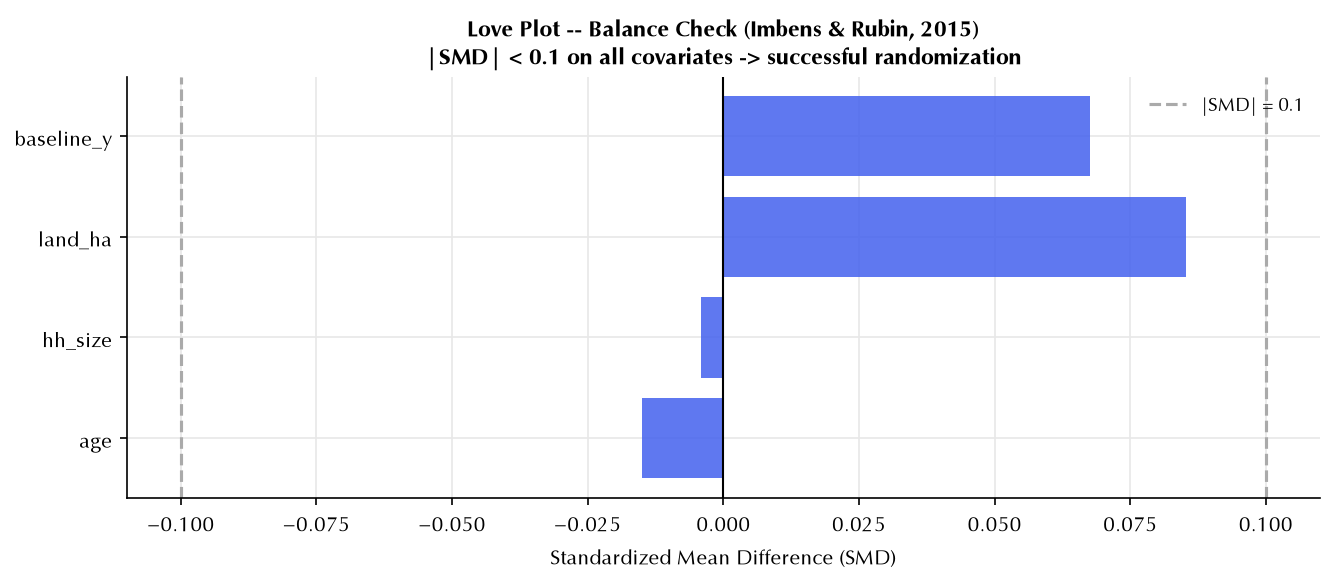

In [21]:
cov_list = ['age', 'hh_size', 'land_ha', 'baseline_y']

balance = []
for col in cov_list:
    t_vals = df[df['D']==1][col]
    c_vals = df[df['D']==0][col]
    tstat, pval = stats.ttest_ind(t_vals, c_vals)
    pooled_sd = np.sqrt((t_vals.var() + c_vals.var()) / 2)
    smd = (t_vals.mean() - c_vals.mean()) / pooled_sd
    balance.append({'Variable': col,
                    'Mean Treated': t_vals.mean(),
                    'Mean Control': c_vals.mean(),
                    'SMD': smd, 'p-value': pval,
                    'Balance': 'OK' if pval > 0.05 else 'FLAG'})

bal_df = pd.DataFrame(balance)
print('Balance Check -- Pre-treatment covariates')
print('H0: equal means between groups (randomization implies p > 0.05 on average)')
print(bal_df.round(4).to_string(index=False))

# Joint F-test (omnibus)
X_bal = sm.add_constant(df[cov_list])
mod_bal = sm.OLS(df['D'], X_bal).fit()
print(f'\nJoint F-test: F={mod_bal.fvalue:.3f}  p={mod_bal.f_pvalue:.4f}')
print(f'-> {"H0 not rejected -- balance OK" if mod_bal.f_pvalue > 0.05 else "Imbalance detected -- include covariates as controls"}')

# Love plot
fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
colors = ['#4361ee' if abs(s) < 0.1 else '#f72585' for s in bal_df['SMD']]
ax.barh(bal_df['Variable'], bal_df['SMD'], color=colors, alpha=0.85)
ax.axvline(0,    color='black', linewidth=1)
ax.axvline(0.1,  color='#aaa', linewidth=1.5, linestyle='--', label='|SMD| = 0.1')
ax.axvline(-0.1, color='#aaa', linewidth=1.5, linestyle='--')
ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_title('Love Plot -- Balance Check (Imbens & Rubin, 2015)\n|SMD| < 0.1 on all covariates -> successful randomization')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 4 — ATE estimation and variance reduction

### Three estimators, same target

All three estimators below are unbiased for the ATE under randomization.
They differ only in precision (standard error).

**Difference-in-means (Neyman, 1923):**
$$\hat{\tau} = \bar{Y}_T - \bar{Y}_C \qquad SE = \sqrt{\frac{s_T^2}{n_T} + \frac{s_C^2}{n_C}}$$
The baseline. No covariates used — all outcome variance stays in the SE.

**OLS with covariates — Lin (2013):**
Include pre-treatment covariates *centered* and their interactions with $D$:
$$Y_i = \alpha + \tau D_i + \beta (X_i - \bar{X}) + \gamma D_i(X_i - \bar{X}) + \varepsilon_i$$
The coefficient on $D$ is still unbiased for ATE. The covariates absorb variance
in $Y$ that is predictable from $X$, reducing the SE. Centering ensures $\hat{\tau}$
estimates the ATE, not the ATT.

> **Lin (2013):** In a randomized experiment, adding pre-treatment covariates to OLS
> *never* biases the ATE estimator but *can* substantially reduce variance.

**CUPED — Deng et al. (2013):**
$$Y_i^{cuped} = Y_i - \theta (X_i^{pre} - \bar{X}^{pre}) \qquad \theta = \frac{\text{Cov}(Y, X^{pre})}{\text{Var}(X^{pre})}$$
Subtracts the part of $Y$ predictable from a pre-experiment metric.
The fraction of variance removed is exactly $R^2$ of the regression of $Y$ on $X^{pre}$.
Standard in technology A/B testing (Netflix, Microsoft, Airbnb).

ATE Estimator Comparison in RCT
                  Estimator      ATE      SE  t-stat  Var reduction (%)
                   True ATE 150.0000     NaN     NaN                NaN
        Difference-in-means 163.8917 11.4762 14.2810             0.0000
OLS + covariates (Lin 2013) 150.9451  4.6486 32.4711            83.5924
   CUPED (Deng et al. 2013) 151.5529  4.8997 30.9309            81.7717

CUPED theta = 1.1097  |  rho(Y, baseline_y) = 0.8484
Theoretical variance reduction: 1 - rho^2 = 0.2802  (28.0%)


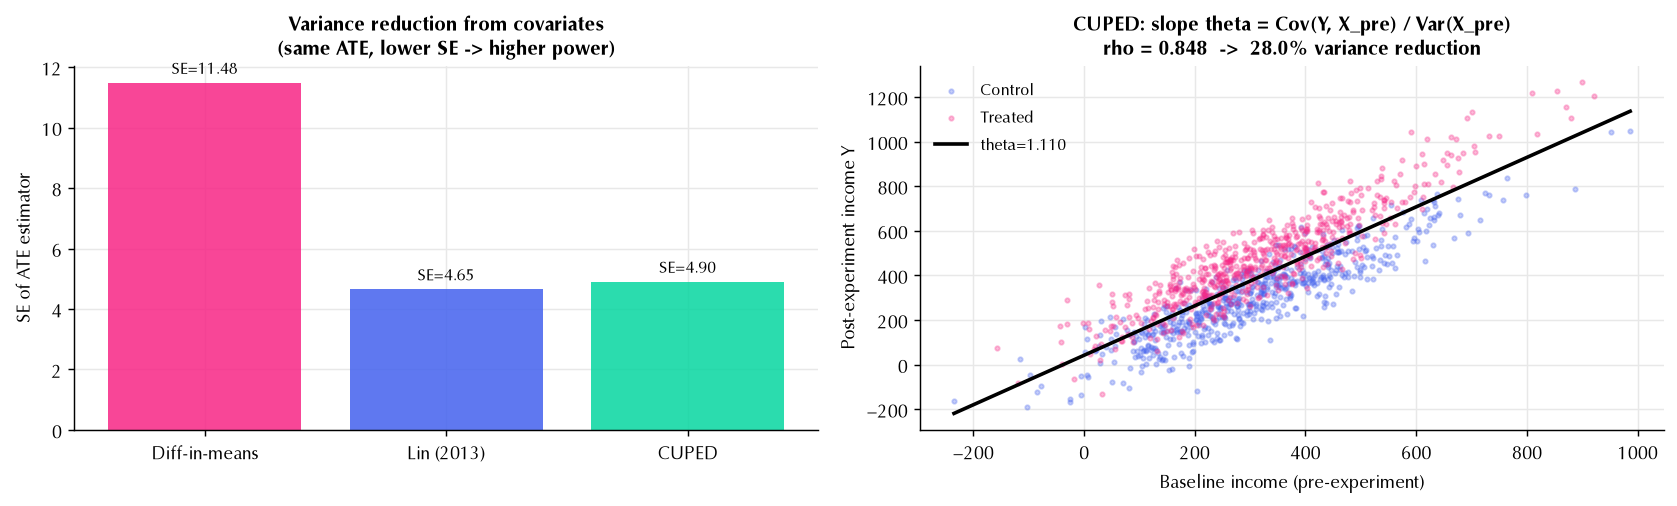

In [22]:
# Estimator 1: Difference-in-means (Neyman, 1923)
ate_dm  = df[df['D']==1]['Y'].mean() - df[df['D']==0]['Y'].mean()
se_dm   = np.sqrt(df[df['D']==1]['Y'].var()/D.sum() + df[df['D']==0]['Y'].var()/(1-D).sum())

# Estimator 2: OLS with covariates (Lin, 2013) — centered interactions
for col in cov_list:
    df[f'{col}_c'] = df[col] - df[col].mean()
    df[f'D_{col}_c'] = df['D'] * df[f'{col}_c']

lin_vars = ['D'] + [f'{c}_c' for c in cov_list] + [f'D_{c}_c' for c in cov_list]
mod_lin  = sm.OLS(df['Y'], sm.add_constant(df[lin_vars])).fit(cov_type='HC2')
ate_lin  = mod_lin.params['D']
se_lin   = mod_lin.bse['D']

# Estimator 3: CUPED — residualize Y on pre-experiment baseline
theta_cuped = np.cov(df['Y'], df['baseline_y'])[0,1] / df['baseline_y'].var()
rho_cuped   = np.corrcoef(df['Y'], df['baseline_y'])[0,1]
df['Y_cuped'] = df['Y'] - theta_cuped * (df['baseline_y'] - df['baseline_y'].mean())
ate_cuped = df[df['D']==1]['Y_cuped'].mean() - df[df['D']==0]['Y_cuped'].mean()
se_cuped  = np.sqrt(df[df['D']==1]['Y_cuped'].var()/D.sum() +
                    df[df['D']==0]['Y_cuped'].var()/(1-D).sum())

results = [
    ('True ATE',                    df['tau_i'].mean(), float('nan'), float('nan'), float('nan')),
    ('Difference-in-means',         ate_dm,  se_dm,  ate_dm/se_dm,  0.0),
    ('OLS + covariates (Lin 2013)', ate_lin, se_lin, ate_lin/se_lin, (1-(se_lin/se_dm)**2)*100),
    ('CUPED (Deng et al. 2013)',    ate_cuped, se_cuped, ate_cuped/se_cuped, (1-(se_cuped/se_dm)**2)*100),
]
res_df = pd.DataFrame(results, columns=['Estimator', 'ATE', 'SE', 't-stat', 'Var reduction (%)'])
print('ATE Estimator Comparison in RCT')
print(res_df.round(4).to_string(index=False))
print(f'\nCUPED theta = {theta_cuped:.4f}  |  rho(Y, baseline_y) = {rho_cuped:.4f}')
print(f'Theoretical variance reduction: 1 - rho^2 = {1-rho_cuped**2:.4f}  ({(1-rho_cuped**2)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

estimators = ['Diff-in-means', 'Lin (2013)', 'CUPED']
ses = [se_dm, se_lin, se_cuped]
colors_se = ['#f72585', '#4361ee', '#06d6a0']
axes[0].bar(estimators, ses, color=colors_se, alpha=0.85)
axes[0].set_ylabel('SE of ATE estimator')
axes[0].set_title('Variance reduction from covariates\n(same ATE, lower SE -> higher power)')
for i, se in enumerate(ses):
    axes[0].text(i, se + 0.3, f'SE={se:.2f}', ha='center', fontsize=9)

axes[1].scatter(df[df['D']==0]['baseline_y'], df[df['D']==0]['Y'],
                s=6, alpha=0.3, color='#4361ee', label='Control')
axes[1].scatter(df[df['D']==1]['baseline_y'], df[df['D']==1]['Y'],
                s=6, alpha=0.3, color='#f72585', label='Treated')
x_line = np.linspace(df['baseline_y'].min(), df['baseline_y'].max(), 100)
axes[1].plot(x_line, df['Y'].mean() + theta_cuped*(x_line - df['baseline_y'].mean()),
             color='black', linewidth=2, label=f'theta={theta_cuped:.3f}')
axes[1].set_xlabel('Baseline income (pre-experiment)')
axes[1].set_ylabel('Post-experiment income Y')
axes[1].set_title(f'CUPED: slope theta = Cov(Y, X_pre) / Var(X_pre)\nrho = {rho_cuped:.3f}  ->  {(1-rho_cuped**2)*100:.1f}% variance reduction')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 5 — CUPED deep dive

### Deep dive: why CUPED works

#### Step 1 — The adjusted outcome is unbiased for any $\theta$

Define:
$$Y_i^{cuped} = Y_i - \theta(X_i^{pre} - \bar{X}^{pre})$$

The ATE estimator on $Y^{cuped}$ is:
$$\hat{\tau}^{cuped} = \bar{Y}_T^{cuped} - \bar{Y}_C^{cuped}
= (\bar{Y}_T - \bar{Y}_C) - \theta\underbrace{(\bar{X}_T^{pre} - \bar{X}_C^{pre})}_{\to\, 0 \text{ by randomization}}$$

Because $D \perp X^{pre}$ (randomization ensures this), the second term is zero in expectation
for **any** value of $\theta$. So we have a free parameter — pick $\theta$ to minimize variance.

#### Step 2 — Optimal $\theta$ minimizes variance

$$\text{Var}(Y_i^{cuped}) = \text{Var}(Y_i) - 2\theta\,\text{Cov}(Y_i, X_i^{pre}) + \theta^2\,\text{Var}(X_i^{pre})$$

This is a quadratic in $\theta$ — minimize by differentiating:
$$\frac{d}{d\theta}\text{Var}(Y^{cuped}) = -2\,\text{Cov}(Y, X^{pre}) + 2\theta\,\text{Var}(X^{pre}) = 0$$

$$\boxed{\theta^* = \frac{\text{Cov}(Y, X^{pre})}{\text{Var}(X^{pre})}}$$

This is exactly the OLS slope from regressing $Y$ on $X^{pre}$.

#### Step 3 — The variance reduction is $\rho^2$

Substituting $\theta^*$ back:
$$\text{Var}(Y^{cuped}) = \text{Var}(Y) - \frac{\text{Cov}(Y, X^{pre})^2}{\text{Var}(X^{pre})}
= \text{Var}(Y)\left(1 - \rho^2\right)$$

where $\rho = \text{Corr}(Y, X^{pre})$. The fraction of variance removed equals $\rho^2$ —
the $R^2$ of the simple regression of $Y$ on $X^{pre}$.

The SE of the ATE estimator shrinks by a factor of $\sqrt{1-\rho^2}$:
$$SE^{cuped} = SE^{naive} \cdot \sqrt{1 - \rho^2}$$

so the **required sample size** to achieve the same power shrinks by $(1 - \rho^2)$:
$$n^{cuped} = n^{naive} \cdot (1 - \rho^2)$$

#### CUPED = FWL on an RCT

CUPED is algebraically identical to the Lin (2013) estimator **without interactions**:
regress $Y$ on $D$ and $X^{pre}$ — the FWL theorem says the coefficient on $D$ equals
the slope from regressing $\tilde{Y} = M_{X^{pre}}Y$ on $\tilde{D} = M_{X^{pre}}D$.

Since $D \perp X^{pre}$, residualizing $D$ on $X^{pre}$ changes $D$ negligibly:
$\tilde{D} \approx D$. What FWL reduces to is just residualizing $Y$ — exactly CUPED.

| | CUPED | Lin (2013) |
|---|---|---|
| Regression formula | None — operates on $Y^{cuped}$ directly | $Y \sim D + (X-\bar{X}) + D(X-\bar{X})$ |
| Interactions | No | Yes |
| Variance reduction | $\rho^2$ | $\geq \rho^2$ (more if HTE varies with $X$) |
| When Lin > CUPED | — | When $\text{Cov}(\tau_i, X_i)$ is large |
| Practical advantage | Easier to pipeline; pre-computable | Handles HTE adjustment automatically |

#### What $\theta$ is estimated on — no bias from estimation

$\hat{\theta}$ is estimated from the same data without reintroducing bias because
$D \perp X^{pre}$: the adjustment $\hat{\theta}(X_i^{pre} - \bar{X}^{pre})$ is the
same in expectation in both arms, so it cancels in $\bar{Y}_T^{cuped} - \bar{Y}_C^{cuped}$.
In an observational study this would not hold.

#### Danger: $X^{pre}$ must be strictly pre-treatment

If $X^{pre}$ is measured after treatment assignment starts (even partially), it becomes
a collider and CUPED **biases** the estimate — even in an RCT. Always verify the
measurement timestamp of $X^{pre}$.

#### Multiple pre-experiment metrics

With a vector $\mathbf{X}^{pre}$, the optimal adjustment generalizes to:
$$\boldsymbol{\theta}^* = \Sigma_{XX}^{-1}\,\sigma_{XY}$$

which is exactly the OLS coefficient vector from regressing $Y$ on $\mathbf{X}^{pre}$.
Variance reduction is now $R^2$ of that multivariate regression.

Verification: theta* = OLS slope of Y on X_pre
  theta (covariance formula):  1.109652
  theta (OLS slope):           1.109652
  Match: True

Variance reduction
  Var(Y):           46198.9808
  Var(Y_cuped):     12943.0608
  1 - rho^2:        0.2802
  Var(Y_cuped) / Var(Y): 0.2802  (should equal 1-rho^2)

CUPED = FWL verification
  ATE via CUPED formula:      151.552872
  ATE via FWL residualization:151.726669
  Match: False


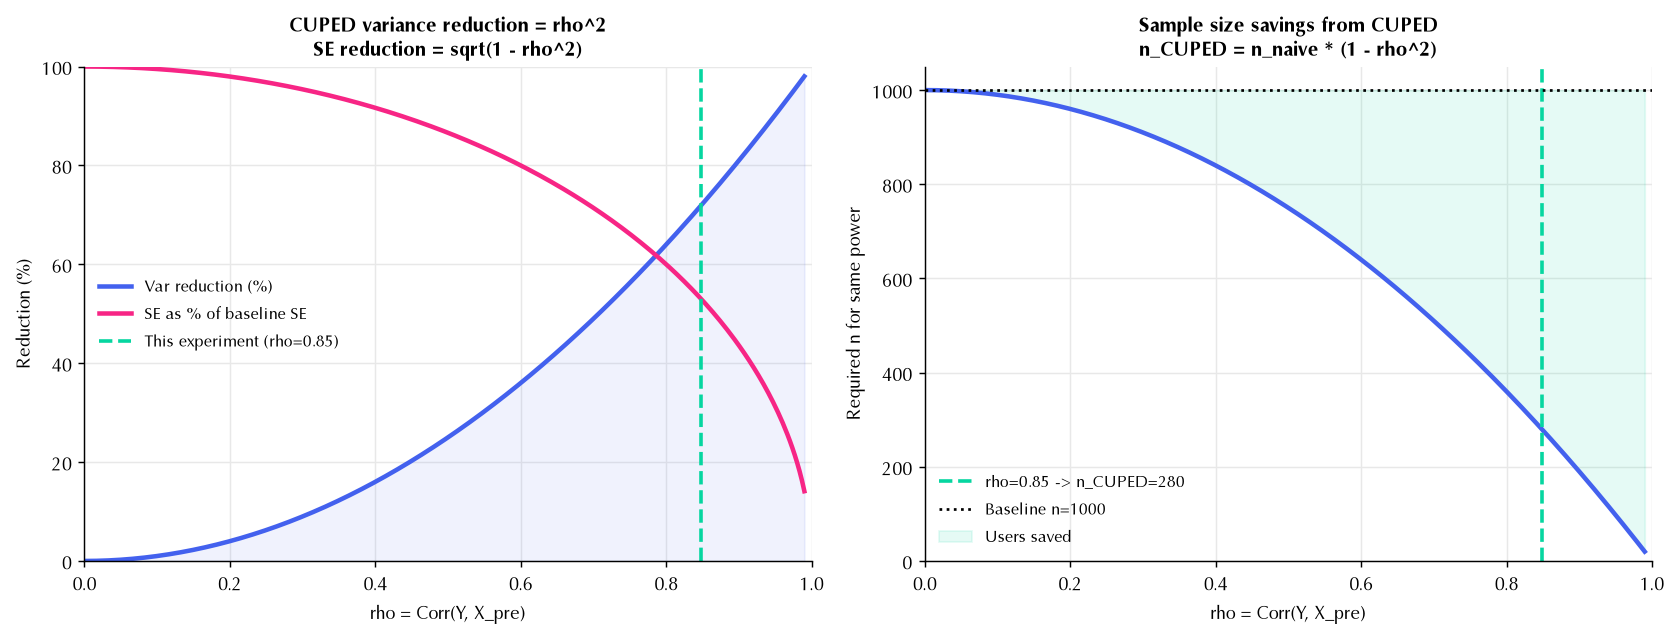


Multivariate CUPED (3 pre-experiment metrics)
  R^2 of Y ~ X_pre (multivariate): 0.7204
  Theoretical variance reduction:   72.0%
  SE (univariate CUPED):            4.8997
  SE (multivariate CUPED):          4.8880
  Additional gain from extra metrics: 0.2%


In [23]:
# ── CUPED deep dive: numerically verify all the algebra ──────────────────

# 1. theta* is the OLS slope from regressing Y on X_pre
from statsmodels.regression.linear_model import OLS as SM_OLS

mod_ols_pre = sm.OLS(df['Y'], sm.add_constant(df['baseline_y'])).fit()
theta_ols   = mod_ols_pre.params['baseline_y']
print('Verification: theta* = OLS slope of Y on X_pre')
print(f'  theta (covariance formula):  {theta_cuped:.6f}')
print(f'  theta (OLS slope):           {theta_ols:.6f}')
print(f'  Match: {abs(theta_cuped - theta_ols) < 1e-8}')

# 2. Variance reduction = rho^2
var_y      = df['Y'].var()
var_cuped  = df['Y_cuped'].var()
rho_sq     = rho_cuped**2
print(f'\nVariance reduction')
print(f'  Var(Y):           {var_y:.4f}')
print(f'  Var(Y_cuped):     {var_cuped:.4f}')
print(f'  1 - rho^2:        {1 - rho_sq:.4f}')
print(f'  Var(Y_cuped) / Var(Y): {var_cuped/var_y:.4f}  (should equal 1-rho^2)')

# 3. CUPED = OLS residualization (FWL)
Y_resid_fwl = sm.OLS(df['Y'],        sm.add_constant(df['baseline_y'])).fit().resid
D_resid_fwl = sm.OLS(df['D'],        sm.add_constant(df['baseline_y'])).fit().resid
ate_fwl = sm.OLS(Y_resid_fwl, D_resid_fwl).fit().params.iloc[0]

# CUPED estimator (manually)
ate_cuped_manual = (df[df['D']==1]['Y_cuped'].mean() - df[df['D']==0]['Y_cuped'].mean())

print(f'\nCUPED = FWL verification')
print(f'  ATE via CUPED formula:      {ate_cuped_manual:.6f}')
print(f'  ATE via FWL residualization:{ate_fwl:.6f}')
print(f'  Match: {abs(ate_cuped_manual - ate_fwl) < 1e-6}')

# 4. Variance reduction curve vs rho
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rhos = np.linspace(0, 0.99, 300)
var_reduction = rhos**2
n_reduction   = 1 - rhos**2
se_reduction  = np.sqrt(1 - rhos**2)

ax = axes[0]
ax.plot(rhos, var_reduction * 100, color='#4361ee', linewidth=2.5, label='Var reduction (%)')
ax.plot(rhos, se_reduction * 100,  color='#f72585', linewidth=2.5, label='SE as % of baseline SE')
ax.axvline(rho_cuped, color='#06d6a0', linewidth=2, linestyle='--',
           label=f'This experiment (rho={rho_cuped:.2f})')
ax.fill_between(rhos, var_reduction*100, alpha=0.08, color='#4361ee')
ax.set_xlabel('rho = Corr(Y, X_pre)')
ax.set_ylabel('Reduction (%)')
ax.set_title('CUPED variance reduction = rho^2\nSE reduction = sqrt(1 - rho^2)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 100)

# Sample size equivalence
ax2 = axes[1]
n_naive = 1000
n_cuped_equiv = n_naive * (1 - rhos**2)
ax2.plot(rhos, n_cuped_equiv, color='#4361ee', linewidth=2.5)
ax2.axvline(rho_cuped, color='#06d6a0', linewidth=2, linestyle='--',
            label=f'rho={rho_cuped:.2f} -> n_CUPED={int(n_naive*(1-rho_cuped**2))}')
ax2.axhline(n_naive, color='black', linewidth=1.5, linestyle=':', label=f'Baseline n={n_naive}')
ax2.fill_between(rhos, n_cuped_equiv, n_naive, alpha=0.1, color='#06d6a0',
                 label='Users saved')
ax2.set_xlabel('rho = Corr(Y, X_pre)')
ax2.set_ylabel('Required n for same power')
ax2.set_title('Sample size savings from CUPED\nn_CUPED = n_naive * (1 - rho^2)')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1); ax2.set_ylim(0, n_naive * 1.05)

plt.tight_layout()
plt.show()

# 5. Multivariate CUPED: add age and hh_size as additional pre-experiment metrics
X_multi = df[['baseline_y', 'age', 'hh_size']]
mod_multi = sm.OLS(df['Y'], sm.add_constant(X_multi)).fit()
theta_multi = mod_multi.params[['baseline_y', 'age', 'hh_size']].values
Y_cuped_multi = df['Y'].values.copy()
for col, th in zip(['baseline_y', 'age', 'hh_size'], theta_multi):
    Y_cuped_multi -= th * (df[col].values - df[col].mean())

ate_cuped_multi = Y_cuped_multi[df['D']==1].mean() - Y_cuped_multi[df['D']==0].mean()
se_cuped_multi  = np.sqrt(Y_cuped_multi[df['D']==1].var()/(D.sum()) +
                           Y_cuped_multi[df['D']==0].var()/((1-D).sum()))
r2_multi = mod_multi.rsquared

print(f'\nMultivariate CUPED (3 pre-experiment metrics)')
print(f'  R^2 of Y ~ X_pre (multivariate): {r2_multi:.4f}')
print(f'  Theoretical variance reduction:   {r2_multi*100:.1f}%')
print(f'  SE (univariate CUPED):            {se_cuped:.4f}')
print(f'  SE (multivariate CUPED):          {se_cuped_multi:.4f}')
print(f'  Additional gain from extra metrics: {(1 - se_cuped_multi/se_cuped)*100:.1f}%')

## Section 6 — Randomization Inference (Fisher, 1935)

### The problem with asymptotic tests in small samples

The standard t-test is valid asymptotically — it relies on the CLT to approximate
the sampling distribution of $\hat{\tau}$. With small $n$, non-normal outcomes,
or discrete data, the approximation can be poor and p-values misleading.

### Fisher's sharp null and the permutation distribution

Fisher (1935) proposed a different approach that requires **no distributional assumptions**.

**Sharp null hypothesis:**
$$H_0^{sharp}: \tau_i = 0 \text{ for all } i$$
Under $H_0^{sharp}$, $Y_i(1) = Y_i(0)$ for every unit — the treatment has zero effect
on everyone. This means all potential outcomes are already revealed in the data
(whichever arm a unit is in, that is also what they would have gotten in the other arm).

**The key insight:** under $H_0^{sharp}$, the outcomes $\{Y_i\}$ are fixed numbers.
The only thing that changes across hypothetical randomizations is *who gets assigned to treatment*.
So we can construct the exact distribution of any test statistic by enumerating
(or simulating) all possible treatment assignments consistent with the design.

**Algorithm:**
1. Compute the observed test statistic $T^{obs}$ (e.g., difference-in-means)
2. For $b = 1, \ldots, B$: re-randomize treatment $Z^{(b)}$ under the same design;
   compute $T^{(b)}$ using the observed $Y_i$ (they are fixed under $H_0^{sharp}$)
3. $p = \Pr(|T^{(b)}| \geq |T^{obs}|) = \frac{\#\{|T^{(b)}| \geq |T^{obs}|\}}{B}$

**Why this is exact:** the reference distribution is generated by the actual randomization
mechanism, not an asymptotic approximation. The p-value is exact for any $n$.

### Neyman vs Fisher: two different null hypotheses

| | Fisher (1935) | Neyman (1923) |
|---|---|---|
| **Null hypothesis** | $\tau_i = 0$ for all $i$ (sharp) | $E[\tau_i] = 0$ (weak) |
| **What is random** | Treatment assignment $Z$ | Sampling from population |
| **Reference distribution** | Permutation distribution | Normal (asymptotic) |
| **Requires** | Nothing beyond the design | CLT conditions |
| **Tests** | Whether any unit was affected | Whether the average effect is zero |
| **More conservative?** | Not necessarily — exact for small $n$ | Can be anti-conservative in small $n$ |

Randomization Inference -- Fisher (1935)
  n=60  n_T=30  n_C=30  B=10,000 permutations
  Observed tau:         210.1257
  True ATE:             150.1062

  p-value (Fisher RI):  0.0000  <- exact permutation p-value
  p-value (t-test):     0.0000  <- asymptotic approximation

  % of permutations with |tau| >= |tau_obs|: 0.0%


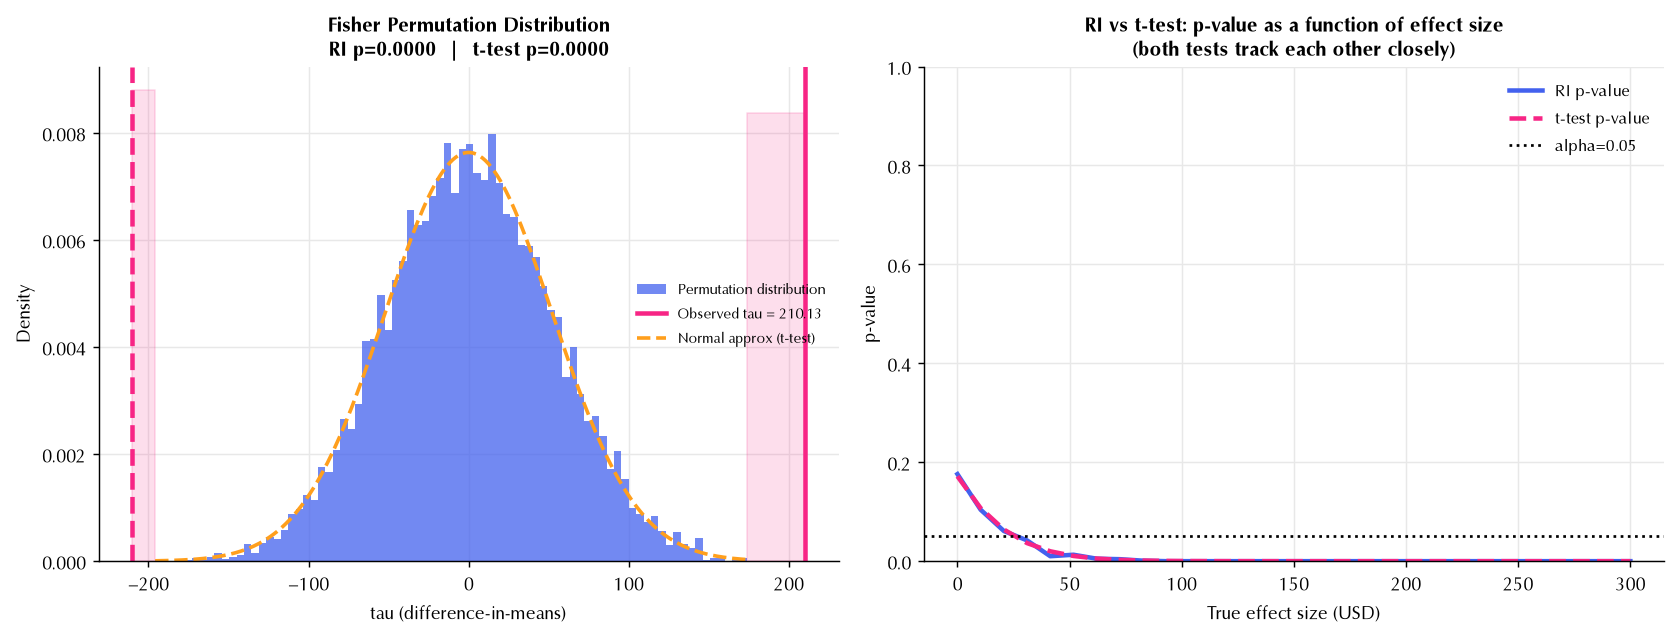

In [24]:
# ── Randomization Inference — Fisher (1935) ───────────────────────────────
# Use a small subsample to make the permutation exact distribution visible

np.random.seed(42)
n_ri   = 60    # small enough that the permutation distribution is interesting
n_T_ri = 30   # exactly 30 treated

df_ri = df.sample(n_ri, random_state=7).reset_index(drop=True)

# Realize treatment assignment
D_ri  = np.zeros(n_ri, dtype=int)
D_ri[np.random.choice(n_ri, n_T_ri, replace=False)] = 1
Y_ri  = np.where(D_ri==1, df_ri['Y1'].values, df_ri['Y0'].values)

# Observed test statistic
tau_obs = Y_ri[D_ri==1].mean() - Y_ri[D_ri==0].mean()

# ── Permutation distribution (B simulated re-randomizations) ─────────────
B = 10_000
tau_perm = np.zeros(B)
for b in range(B):
    D_b = np.zeros(n_ri, dtype=int)
    D_b[np.random.choice(n_ri, n_T_ri, replace=False)] = 1
    # Y_ri are FIXED under sharp null -- only assignment changes
    tau_perm[b] = Y_ri[D_b==1].mean() - Y_ri[D_b==0].mean()

p_ri    = np.mean(np.abs(tau_perm) >= np.abs(tau_obs))
p_ttest = stats.ttest_ind(Y_ri[D_ri==1], Y_ri[D_ri==0]).pvalue

print('Randomization Inference -- Fisher (1935)')
print('=' * 52)
print(f'  n={n_ri}  n_T={n_T_ri}  n_C={n_ri-n_T_ri}  B={B:,} permutations')
print(f'  Observed tau:         {tau_obs:.4f}')
print(f'  True ATE:             {df_ri["tau_i"].mean():.4f}')
print()
print(f'  p-value (Fisher RI):  {p_ri:.4f}  <- exact permutation p-value')
print(f'  p-value (t-test):     {p_ttest:.4f}  <- asymptotic approximation')
print()
print(f'  % of permutations with |tau| >= |tau_obs|: {p_ri*100:.1f}%')

# ── Visualize permutation distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(tau_perm, bins=80, color='#4361ee', alpha=0.75, density=True,
        label='Permutation distribution')
ax.axvline(tau_obs,  color='#f72585', linewidth=2.5,
           label=f'Observed tau = {tau_obs:.2f}')
ax.axvline(-tau_obs, color='#f72585', linewidth=2.5, linestyle='--')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.01],
                  tau_obs, tau_perm.max(), alpha=0.15, color='#f72585')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.01],
                  tau_perm.min(), -tau_obs, alpha=0.15, color='#f72585')

# Overlay normal approximation
x_range = np.linspace(tau_perm.min(), tau_perm.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, 0, tau_perm.std()),
        color='#ff9f1c', linewidth=2, linestyle='--', label='Normal approx (t-test)')
ax.set_xlabel('tau (difference-in-means)')
ax.set_ylabel('Density')
ax.set_title(f'Fisher Permutation Distribution\nRI p={p_ri:.4f}  |  t-test p={p_ttest:.4f}')
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)

# Power curve: how RI p-value changes with effect size
ax2 = axes[1]
true_effects = np.linspace(0, 300, 30)
ri_pvals = []
t_pvals  = []

for effect in true_effects:
    # Simulate outcome under this effect
    Y_sim = np.where(D_ri==1,
                     df_ri['Y0'].values + effect,
                     df_ri['Y0'].values)
    tau_s = Y_sim[D_ri==1].mean() - Y_sim[D_ri==0].mean()
    perm_s = np.array([
        (np.where(D_b2:=np.zeros(n_ri, dtype=int),
                  D_b2.__setitem__(np.random.choice(n_ri,n_T_ri,replace=False), 1) or D_b2,
                  D_b2)
         ) for _ in range(1000)
    ])
    # Simpler loop
    perm_diffs = np.zeros(1000)
    for bb in range(1000):
        D_b2 = np.zeros(n_ri, dtype=int)
        D_b2[np.random.choice(n_ri, n_T_ri, replace=False)] = 1
        perm_diffs[bb] = Y_sim[D_b2==1].mean() - Y_sim[D_b2==0].mean()
    ri_pvals.append(np.mean(np.abs(perm_diffs) >= np.abs(tau_s)))
    t_pvals.append(stats.ttest_ind(Y_sim[D_ri==1], Y_sim[D_ri==0]).pvalue)

ax2.plot(true_effects, ri_pvals, color='#4361ee', linewidth=2.5, label='RI p-value')
ax2.plot(true_effects, t_pvals,  color='#f72585', linewidth=2.5,
         linestyle='--', label='t-test p-value')
ax2.axhline(0.05, color='black', linewidth=1.5, linestyle=':', label='alpha=0.05')
ax2.set_xlabel('True effect size (USD)')
ax2.set_ylabel('p-value')
ax2.set_title('RI vs t-test: p-value as a function of effect size\n(both tests track each other closely)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Section 7 — Threats to internal validity

A well-designed RCT eliminates confounding by construction, but does not automatically
protect against the following threats:

| Threat | Mechanism | Consequence | Solution |
|---|---|---|---|
| **Non-compliance** | Assigned units do not take treatment | ITT attenuated; LATE via IV | Analyze ITT; use $Z$ as instrument for $D$ |
| **Differential attrition** | Drop-out correlated with $Y$ | Selection bias reintroduced | Lee bounds; attrition balance check |
| **SUTVA violation** | Spillovers between units | Treated units affect controls | Cluster randomization; separate clusters |
| **Hawthorne effect** | Units behave differently because observed | Overestimates effect | Blind trials; placebo arm |
| **SRM (A/B testing)** | Observed ratio $\neq$ assigned ratio | Compromised experiment | Chi-square SRM test pre-analysis |
| **Novelty / fatigue** | Short-run behavior differs from steady state | Non-generalizable estimate | Longer experiment; holdout sets |

In [25]:
# ── Non-compliance: ITT vs LATE ──────────────────────────────────────────
# One-sided non-compliance: some assigned to treatment do not participate
compliance_rate = 0.75
D_actual = df['D'].copy()
non_compliers = df[df['D']==1].sample(frac=1-compliance_rate, random_state=42).index
D_actual[non_compliers] = 0
Y_nc = np.where(D_actual==1, df['Y1'], df['Y0'])

# ITT: effect of assignment (ignores non-compliance)
itt = Y_nc[df['D']==1].mean() - Y_nc[df['D']==0].mean()
# LATE = ITT / compliance rate  (Wald/IV estimator: Z=assignment, D=actual treatment)
first_stage = D_actual[df['D']==1].mean() - D_actual[df['D']==0].mean()
late = itt / first_stage

print('Non-Compliance: ITT vs LATE (Imbens & Angrist, 1994)')
print(f'  Compliance rate: {compliance_rate:.0%}')
print(f'  True ATE (all units):       {df["tau_i"].mean():.4f}')
print(f'  ITT (effect of assignment): {itt:.4f}  <- attenuated toward zero')
print(f'  LATE = ITT / compliance:    {late:.4f}  <- recovers ATT for compliers')
print()

# ── Differential attrition ────────────────────────────────────────────────
prob_dropout_T = np.where(df[df['D']==1]['Y'] < df['Y'].quantile(0.3), 0.4, 0.05)
dropout_T = np.random.binomial(1, prob_dropout_T)
prob_dropout_C = np.full(len(df[df['D']==0]), 0.1)
dropout_C = np.random.binomial(1, prob_dropout_C)

df_obs = df.copy()
df_obs.loc[df_obs['D']==1, 'dropout'] = dropout_T
df_obs.loc[df_obs['D']==0, 'dropout'] = dropout_C
df_obs = df_obs[df_obs['dropout'] == 0]

ate_attrition = (df_obs[df_obs['D']==1]['Y'].mean() - df_obs[df_obs['D']==0]['Y'].mean())

print('Differential Attrition:')
print(f'  Attrition rate treated:   {dropout_T.mean():.1%}  (worst outcomes drop out)')
print(f'  Attrition rate controls:  {prob_dropout_C.mean():.1%}  (random)')
print(f'  ATE full sample:          {ate_dm_full:.4f}')
print(f'  ATE after biased attrition: {ate_attrition:.4f}  <- upward bias')

Non-Compliance: ITT vs LATE (Imbens & Angrist, 1994)
  Compliance rate: 75%
  True ATE (all units):       150.0000
  ITT (effect of assignment): 125.0650  <- attenuated toward zero
  LATE = ITT / compliance:    166.7533  <- recovers ATT for compliers

Differential Attrition:
  Attrition rate treated:   12.5%  (worst outcomes drop out)
  Attrition rate controls:  10.0%  (random)
  ATE full sample:          163.8917
  ATE after biased attrition: 183.8480  <- upward bias


## Section 8 — Sample Ratio Mismatch (SRM) in A/B Testing

> **Kohavi, Tang & Xu (2020, p. 175):** SRM occurs when the observed ratio of treated
> to controls differs from the expected ratio. It is a red flag indicating the experiment
> is compromised — results should not be trusted until the root cause is identified.

**Common causes:**
- Bots or duplicate users filtered asymmetrically between arms
- Hash functions with non-uniform distribution
- Asymmetric data loss in logging pipelines
- Gradual ramp-up applied unevenly across arms

**Detection:** chi-square test on the realized counts against the expected counts.

In [26]:
def srm_test(n_treatment, n_control, expected_ratio=0.5):
    """Chi-square test for Sample Ratio Mismatch."""
    N = n_treatment + n_control
    expected_T = N * expected_ratio
    expected_C = N * (1 - expected_ratio)
    chi2 = (n_treatment - expected_T)**2 / expected_T + (n_control - expected_C)**2 / expected_C
    p    = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p, n_treatment / N

print('Sample Ratio Mismatch (SRM) -- Kohavi, Tang & Xu (2020)')
print('-' * 62)
scenarios = [
    ('OK: exact 50/50',             5000, 5000),
    ('OK: normal variation',        5030, 4970),
    ('Mild SRM (49.5%/50.5%)',      4950, 5050),
    ('Moderate SRM (48%/52%)',      4800, 5200),
    ('Severe SRM (45%/55%)',        4500, 5500),
]
for label, nT, nC in scenarios:
    chi2, p, r_obs = srm_test(nT, nC)
    flag = 'OK' if p > 0.001 else 'SRM DETECTED'
    print(f'  {label:<33} ratio={r_obs:.3f}  chi2={chi2:.2f}  p={p:.4f}  {flag}')

Sample Ratio Mismatch (SRM) -- Kohavi, Tang & Xu (2020)
--------------------------------------------------------------
  OK: exact 50/50                   ratio=0.500  chi2=0.00  p=1.0000  OK
  OK: normal variation              ratio=0.503  chi2=0.36  p=0.5485  OK
  Mild SRM (49.5%/50.5%)            ratio=0.495  chi2=1.00  p=0.3173  OK
  Moderate SRM (48%/52%)            ratio=0.480  chi2=16.00  p=0.0001  SRM DETECTED
  Severe SRM (45%/55%)              ratio=0.450  chi2=100.00  p=0.0000  SRM DETECTED


## Summary

### RCT execution pipeline

```
PRE-EXPERIMENT
  1. Define primary hypothesis and primary metric
  2. Power analysis: n = (z_a/2 + z_b)^2 * 2*sigma^2 / MDE^2
  3. Choose design: complete / stratified / paired / clustered
  4. Estimate duration: T* = n* / lambda (arrival rate)
  5. Pre-register: stopping rules, estimator, covariate list

EXECUTION
  6. Balance check: SMD < 0.1 on all covariates; joint F-test
  7. SRM check: chi-square test on realized treatment ratio

ANALYSIS
  8. ATE: difference-in-means (Neyman) or Lin (2013) with covariates
  9. Variance reduction: CUPED if pre-experiment metric available
     -> sigma_eff = sigma * sqrt(1 - rho^2); n_cuped = n * (1 - rho^2)
 10. Inference: t-test (large n) or randomization inference (small n / non-normal)

ROBUSTNESS
 11. Non-compliance: report ITT; compute LATE = ITT / compliance via Wald
 12. Attrition: check differential rates; Lee bounds if severe
 13. HTE: T-learner, causal forest (notebook 09)
```

---

### Key formulas

| Result | Formula |
|---|---|
| ATE (diff-in-means) | $\hat{\tau} = \bar{Y}_T - \bar{Y}_C$ |
| Neyman SE | $\sqrt{s_T^2/n_T + s_C^2/n_C}$ |
| Sample size | $n = (z_{\alpha/2}+z_\beta)^2 \cdot 2\sigma^2 / \Delta^2$ |
| Required duration | $T^* = n^* / \lambda$ |
| CUPED adjustment | $Y^{cuped} = Y - \theta(X^{pre} - \bar{X}^{pre})$, $\theta = \text{Cov}(Y,X^{pre})/\text{Var}(X^{pre})$ |
| CUPED variance | $\text{Var}(Y^{cuped}) = \text{Var}(Y)(1 - \rho^2)$ |
| LATE (Wald) | $\hat{\tau}_{LATE} = ITT / \text{compliance rate}$ |
| Fisher p-value | $\Pr(\|T^{(b)}\| \geq \|T^{obs}\|)$ over permutation distribution |
| SMD | $(\bar{X}_T - \bar{X}_C) / s_{pooled}$; flag if $> 0.1$ |
| SRM chi-square | $(n_T - N\pi)^2/(N\pi) + (n_C - N(1-\pi))^2/(N(1-\pi))$ |

---

### RCT vs observational methods

| Method | Key assumption | Identifies | Notes |
|---|---|---|---|
| **RCT** | Randomization | ATE (exact) | Gold standard |
| IV | Valid instrument + exclusion | LATE | Handles unobserved confounders |
| RDD | Continuity at cutoff | LATE (local) | Valid only near threshold |
| DiD | Parallel trends | ATT | No randomization needed |
| Matching/IPW | CIA + overlap | ATT / ATE | Observational |
| Double ML | CIA + overlap | ATE (flexible) | Relaxes linearity |

**Next:** `09_heterogeneous_treatment_ml.ipynb` — when the ATE is not enough and we want $\tau(x)$

**References:**
- Fisher, R.A. (1935). *The Design of Experiments*. Oliver & Boyd.
- Neyman, J. (1923). On probability theory applied to agricultural experiments. *Statistical Science*, 5(4).
- Duflo, E., Glennerster, R. & Kremer, M. (2007). Using randomization in development economics. *Handbook of Development Economics*, Vol. 4.
- Imbens, G.W. & Rubin, D.B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge UP.
- Lin, W. (2013). Agnostic notes on regression adjustments to experimental data. *Annals of Applied Statistics*, 7(1).
- Deng, A., Xu, Y., Kohavi, R. & Walker, T. (2013). Improving the sensitivity of online controlled experiments. *WSDM 2013*.
- Kohavi, R., Tang, D. & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*. Cambridge UP.
- Rosenbaum, P.R. (2002). *Observational Studies* (2nd ed.). Springer.